# Figure 3E — Dot plots

Split out from `figure_2F_refactored (2).ipynb`.
Uses cached differential expression from `derived/differential_expression.parquet`.


In [17]:
print('hello')
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scanpy as sc
from matplotlib import rc_context
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)



hello


In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Close any open figures
plt.close('all')

# Reset seaborn + matplotlib to defaults
try:
    sns.reset_defaults()
except Exception:
    pass
mpl.rcdefaults()
plt.style.use('default')  # extra belt-and-braces


In [19]:
# --- imports ---
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns

# --- palette (your spec) ---
palette = sns.color_palette("Set3", n_colors=4)
castes = ["queen", "king", "soldier", "worker"]
palette_dict = dict(zip(castes, palette))

# --- params ---
cell_type_col = "paper_cell_type_annotation"
caste_col = "caste"
target_castes = ["queen", "king", "soldier"]
reference_caste = "worker"
alpha = 0.05

# ============================================================
# Load precomputed differential expression
# ============================================================
DE_PATH = "/home/catherine/phd/projects/termites/code/znev_analysis/paper_code/fig_2/derived/differential_expression.parquet"
differential_expression = pd.read_parquet(DE_PATH)

pcol = "pvals_adj" if differential_expression["pvals_adj"].notna().any() else "pvals"

# quick sanity: how many comparisons?
print(differential_expression[["cell_type","caste"]].drop_duplicates().shape[0], "cell_type×caste comparisons")


66 cell_type×caste comparisons


In [20]:
# --- Imports ---
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3, venn3_circles

# ---------------- Palette (your spec) ----------------
palette = sns.color_palette("Set3", n_colors=4)
castes = ["queen", "king", "soldier", "worker"]
palette_dict = dict(zip(castes, palette))

# ---------------- Parameters ----------------
cell_type_col = "paper_cell_type_annotation"
caste_col = "caste"
target_castes = ["queen", "king", "soldier"]
reference_caste = "worker"
alpha = 0.05

# Column in adata.var to use for pretty labels (Fly ortholog symbol)
label_col = "dmel_gene_symbol"

# ============================================================
# 1) Load precomputed differential expression
# ============================================================


pcol = "pvals_adj" if differential_expression["pvals_adj"].notna().any() else "pvals"

de = differential_expression[
    (differential_expression["reference_caste"] == reference_caste) &
    (differential_expression["caste"].isin(target_castes))
].copy()

sig_up = de[(de[pcol] < alpha) & (de["logfoldchanges"] > 0)].copy()

# ============================================================
# 2) Build:
#    - up_sets[cell_type][caste] -> set of up genes
#    - de_tables[cell_type][caste] -> DataFrame of filtered DE (up only)
# ============================================================
cell_types = list(pd.unique(adata.obs[cell_type_col]))

up_sets = {ct: {c: set() for c in target_castes} for ct in cell_types}
de_tables = {ct: {c: pd.DataFrame(columns=["names","scores","logfoldchanges","pvals_adj","pvals"]) for c in target_castes} for ct in cell_types}

for (ct, caste), grp in sig_up.groupby(["cell_type","caste"], sort=False):
    genes = grp["names"].astype(str).tolist()
    up_sets.setdefault(ct, {})[caste] = set(genes)
    # keep consistent columns expected later
    cols = ["names","scores","logfoldchanges","pvals_adj","pvals"]
    tmp = grp.copy()
    for col in cols:
        if col not in tmp.columns:
            tmp[col] = np.nan
    de_tables.setdefault(ct, {})[caste] = tmp[cols]

# ============================================================
# 3) Summarize uniques / pairwise-only / all-three per cell type
# ============================================================
rows = []
for ct, d in up_sets.items():
    S = d.get("soldier", set())
    K = d.get("king", set())
    Q = d.get("queen", set())

    all_three = S & K & Q

    # pairwise-only (exclude all_three)
    SK_only = (S & K) - all_three
    SQ_only = (S & Q) - all_three
    KQ_only = (K & Q) - all_three

    # uniques
    S_only = S - (K | Q)
    K_only = K - (S | Q)
    Q_only = Q - (S | K)

    union_any = S | K | Q

    rows.append({
        "cell_type": ct,
        "soldier_total": len(S),
        "king_total": len(K),
        "queen_total": len(Q),
        "unique_soldier": len(S_only),
        "unique_king": len(K_only),
        "unique_queen": len(Q_only),
        "soldier_king_only": len(SK_only),
        "soldier_queen_only": len(SQ_only),
        "king_queen_only": len(KQ_only),
        "all_three": len(all_three),
        "any_up": len(union_any),
    })

up_overlap_summary = pd.DataFrame(rows).sort_values("cell_type")
print(up_overlap_summary.head())

                     cell_type  soldier_total  king_total  queen_total  \
16                  CNS neuron              0           0            4   
21  Malpighian tubule stellate              0           0            0   
8                           T1              0           0            0   
19                          T2             10          14           62   
5                           T3             26          25          285   

    unique_soldier  unique_king  unique_queen  soldier_king_only  \
16               0            0             4                  0   
21               0            0             0                  0   
8                0            0             0                  0   
19               5            5            51                  0   
5               17           10           266                  1   

    soldier_queen_only  king_queen_only  all_three  any_up  
16                   0                0          0       4  
21                   0  

T5


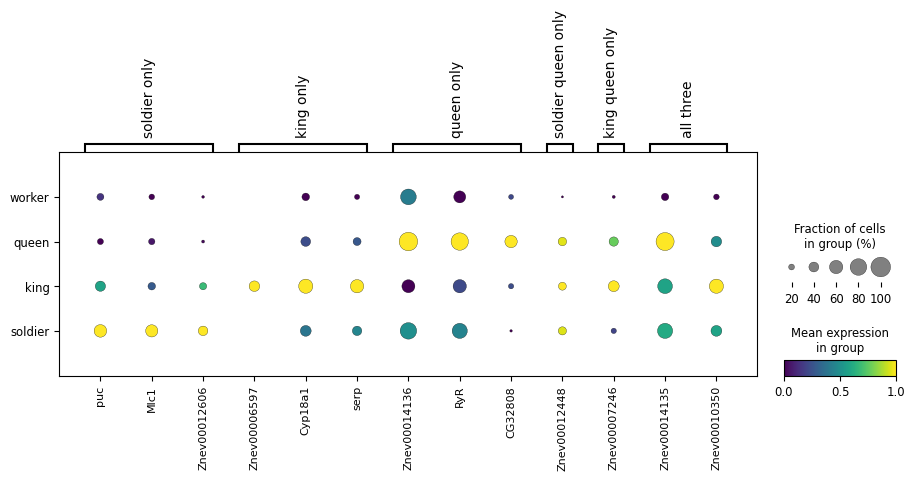

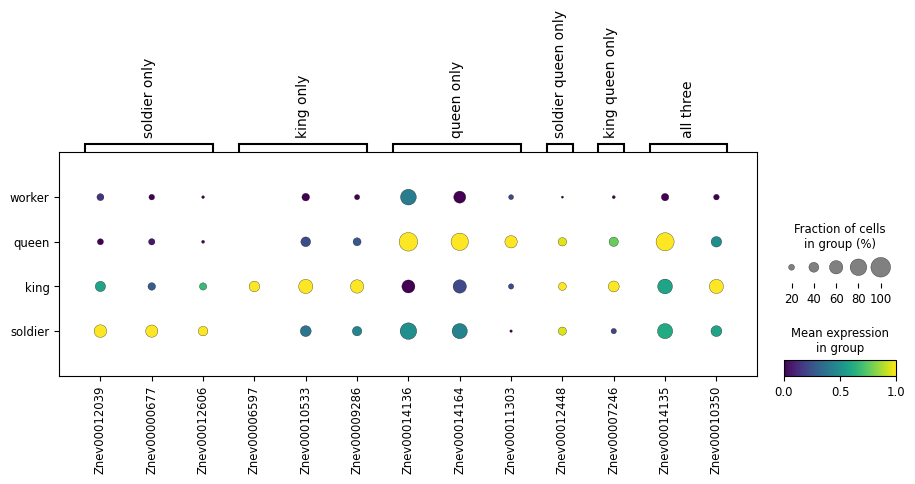

epithelial


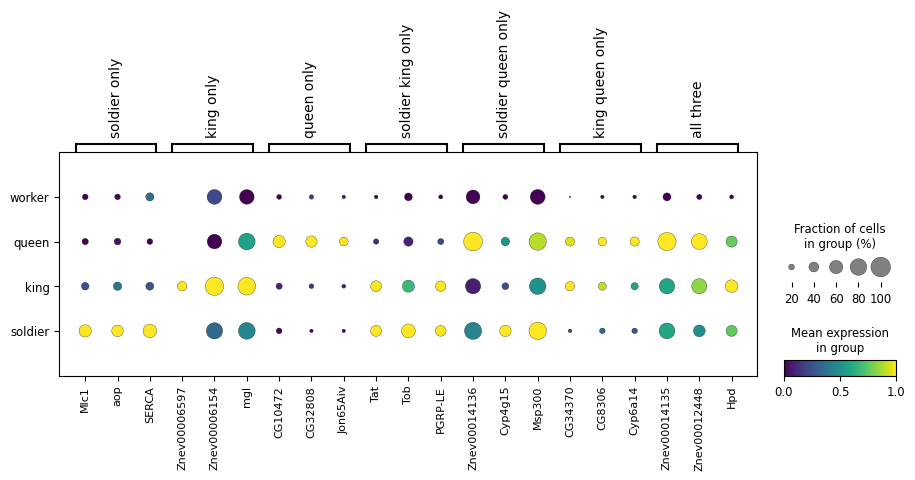

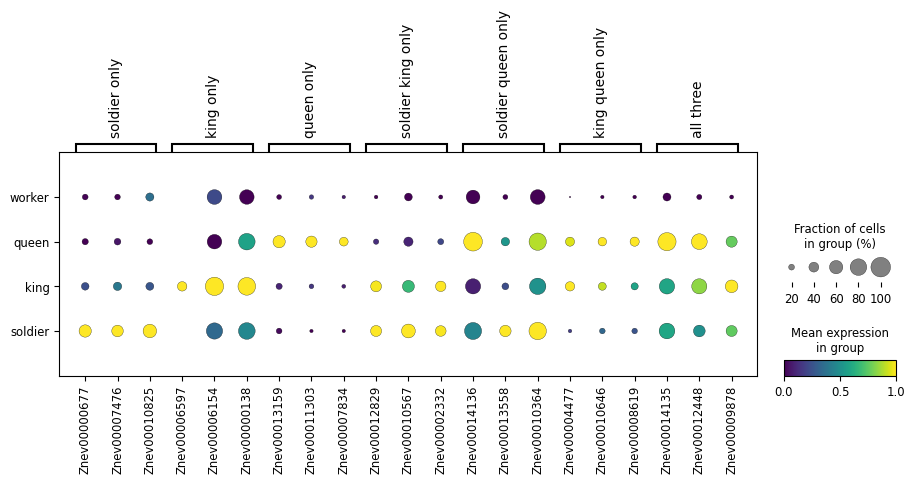

stem cell


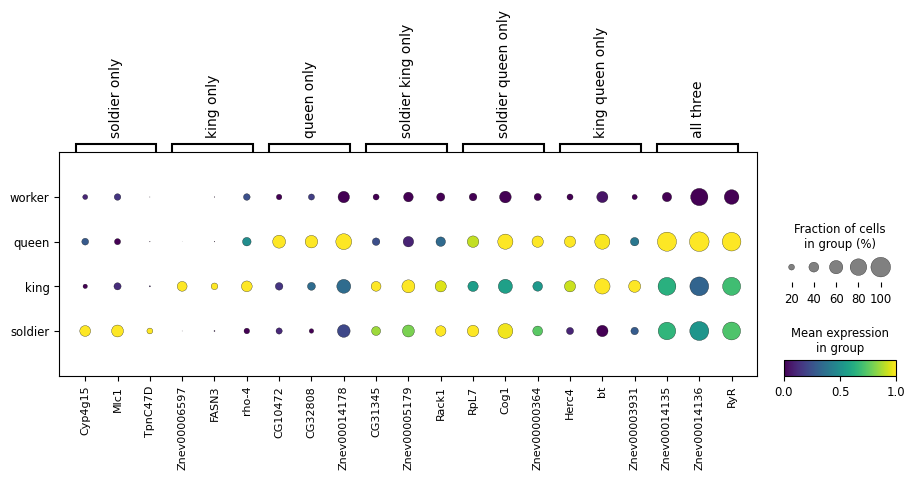

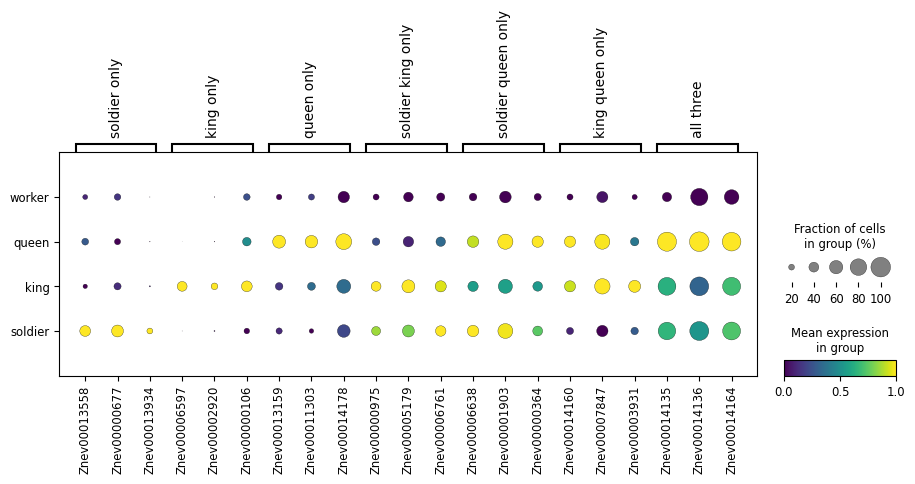

sensory neuron


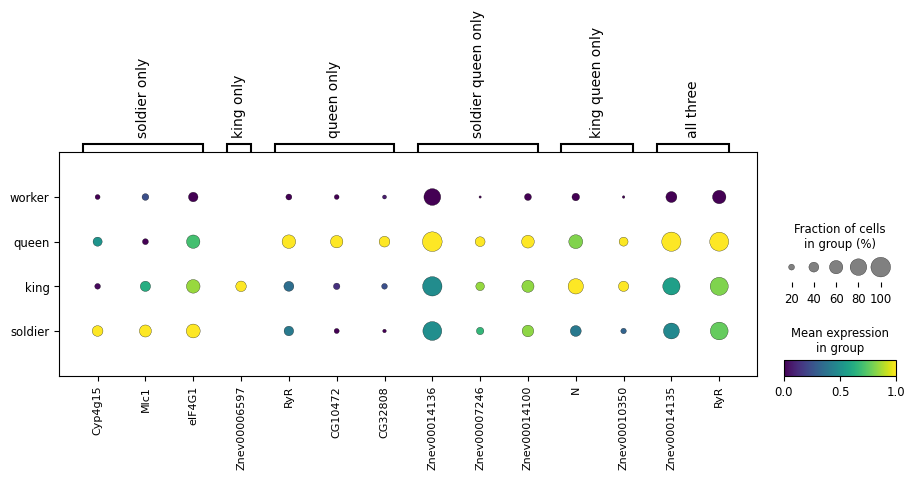

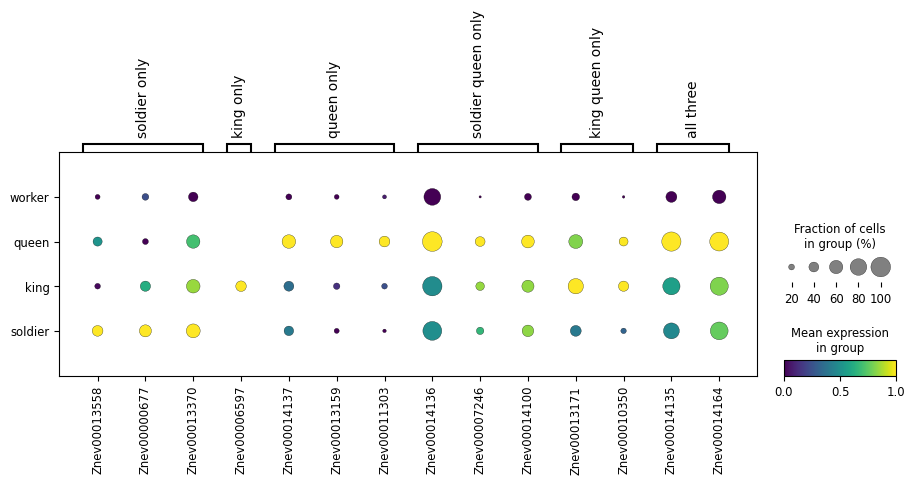

fat cell


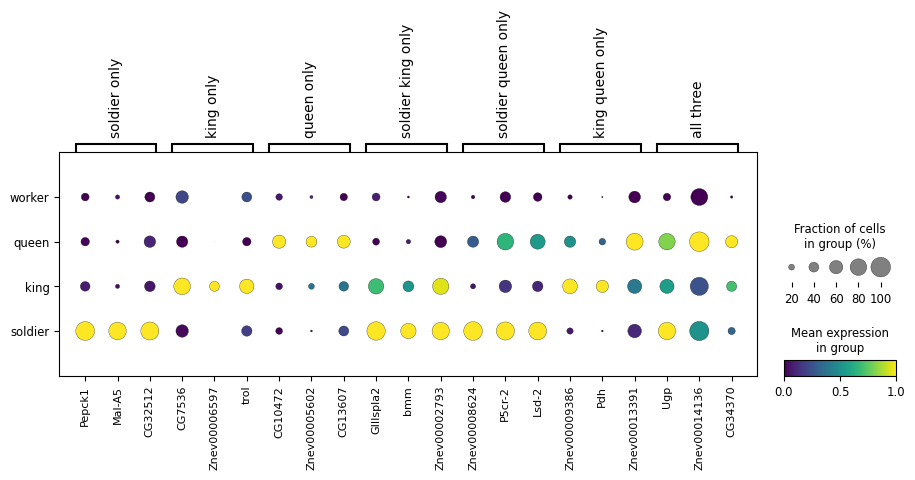

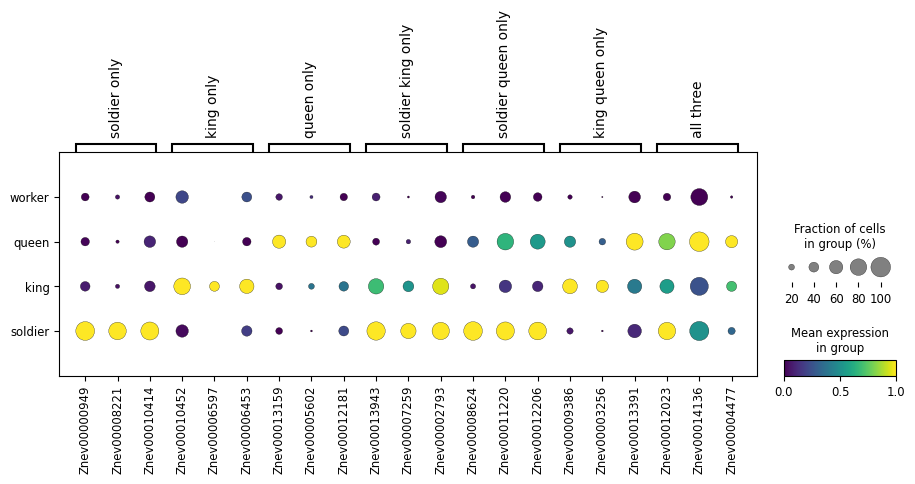

T3


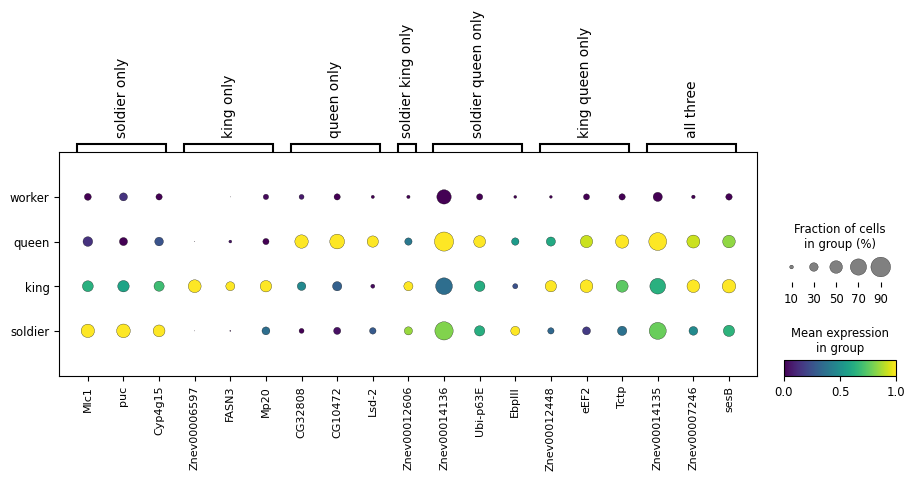

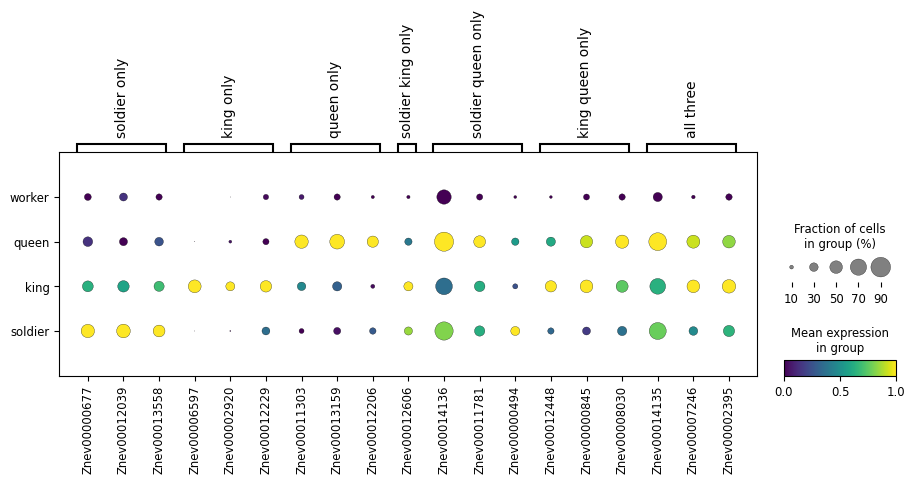

glial cell


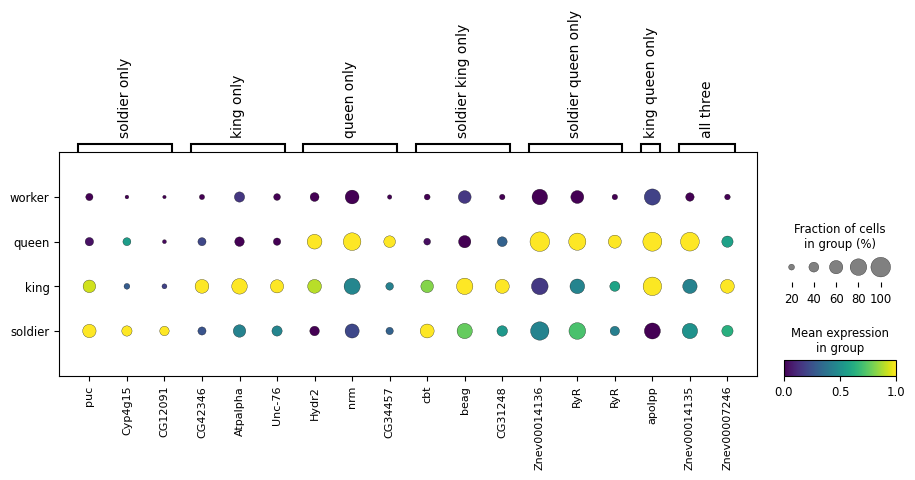

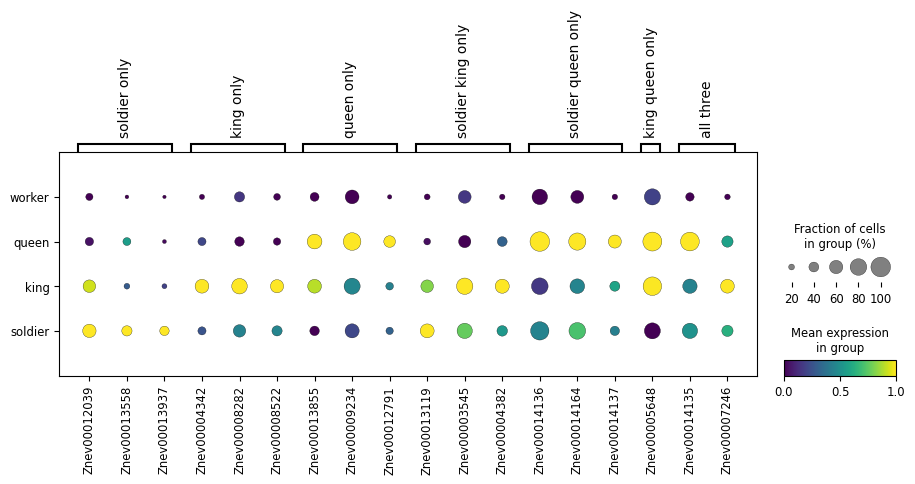

muscle cell


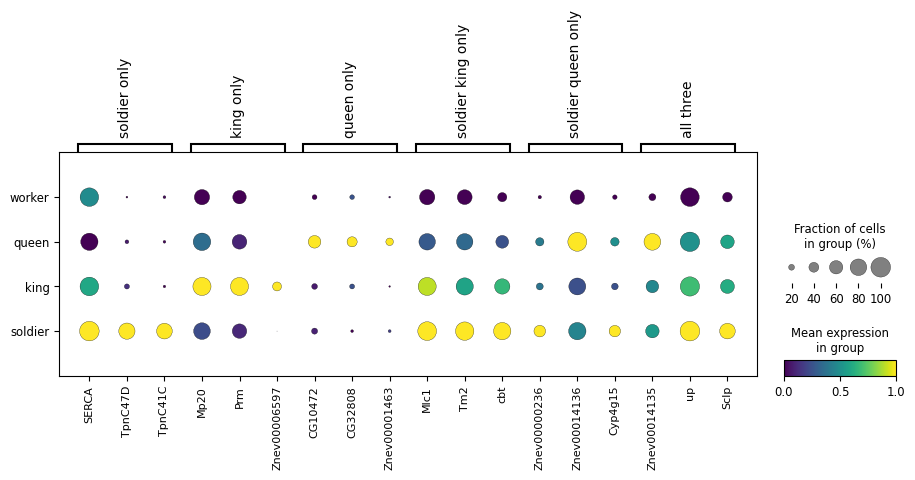

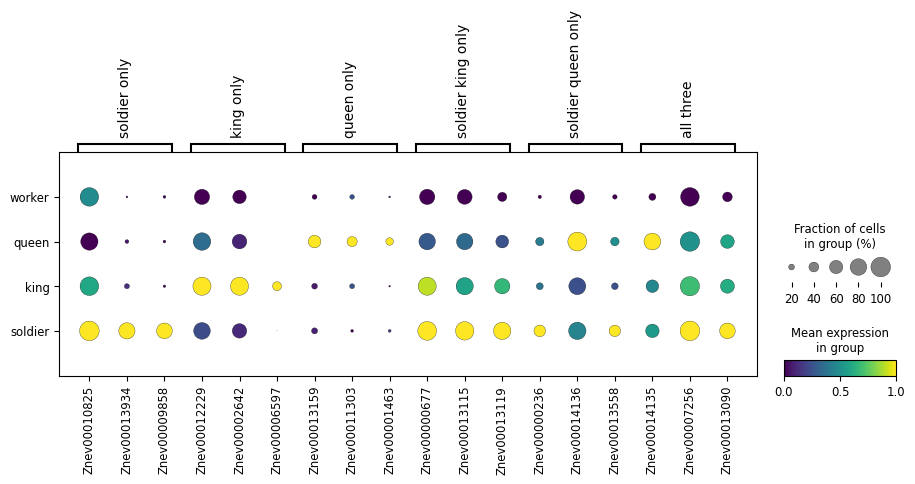

[INFO] T1: no genes to plot.
neuron


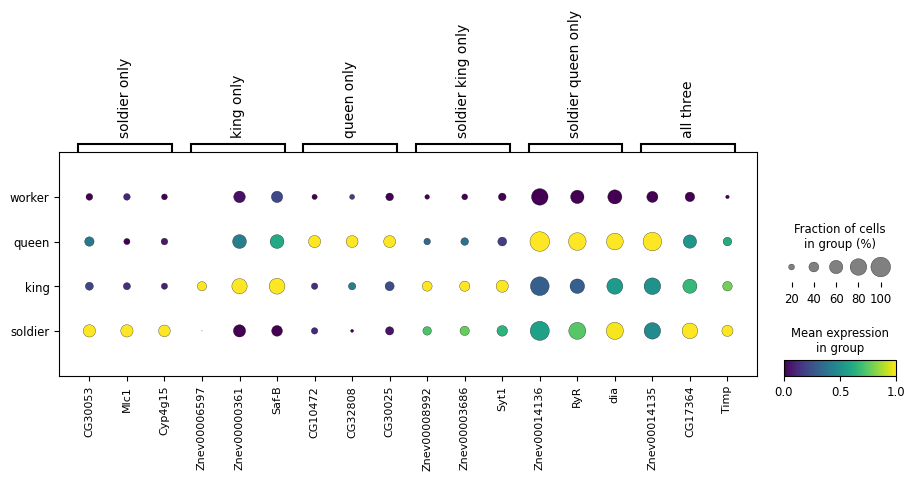

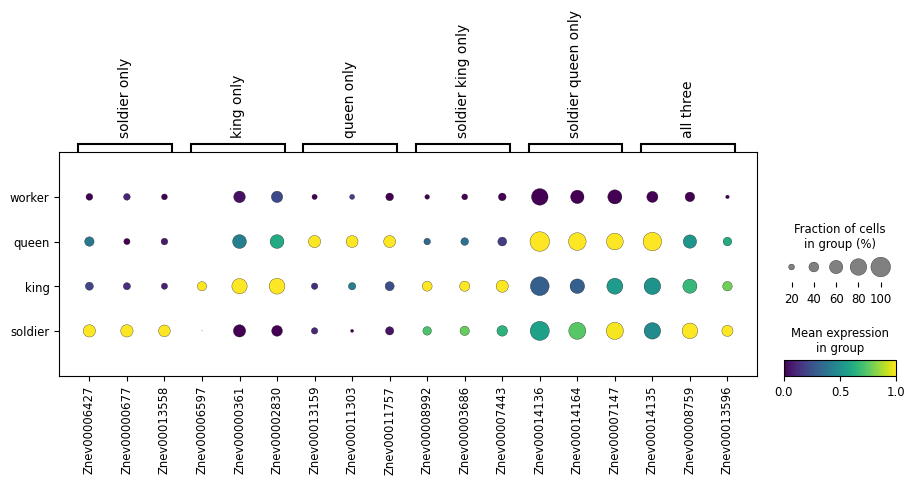

T6


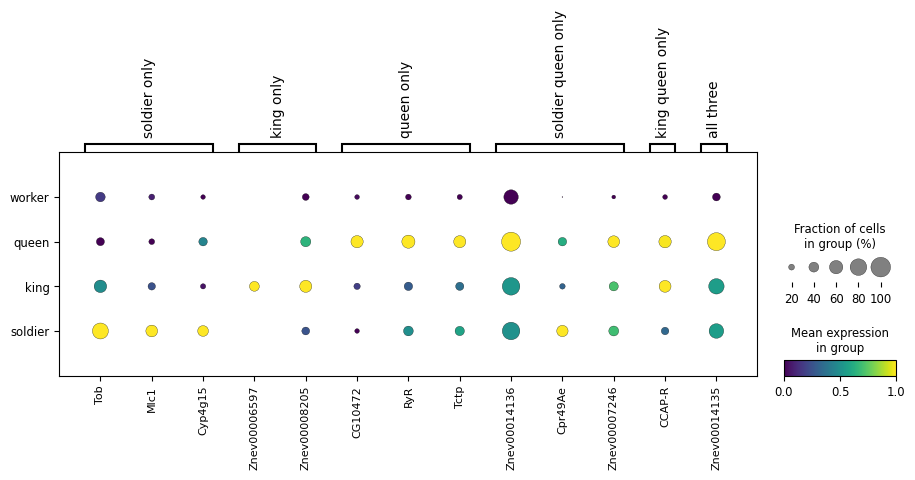

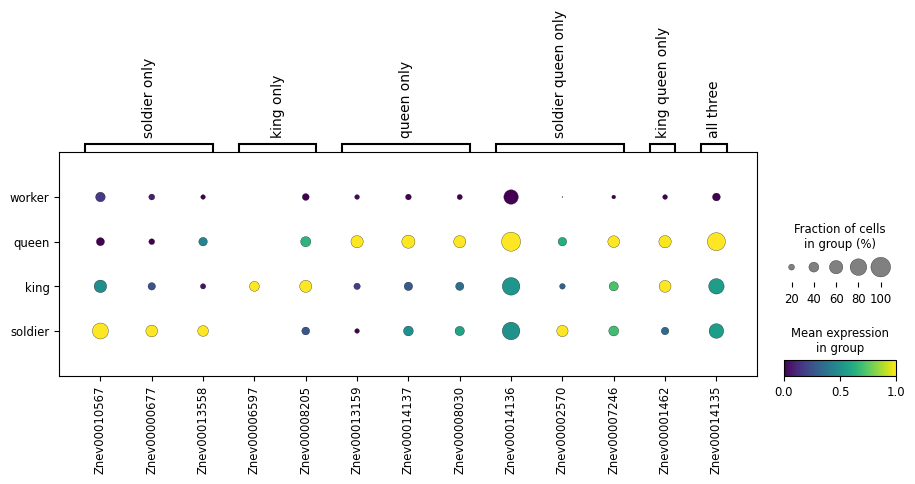

T4


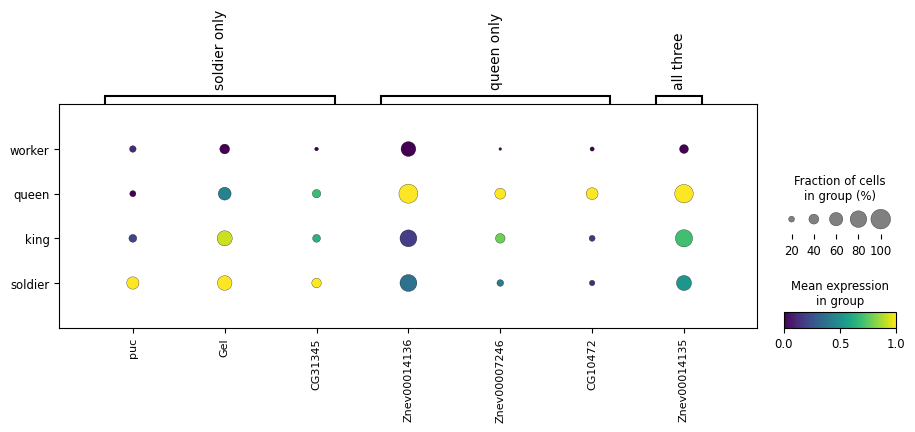

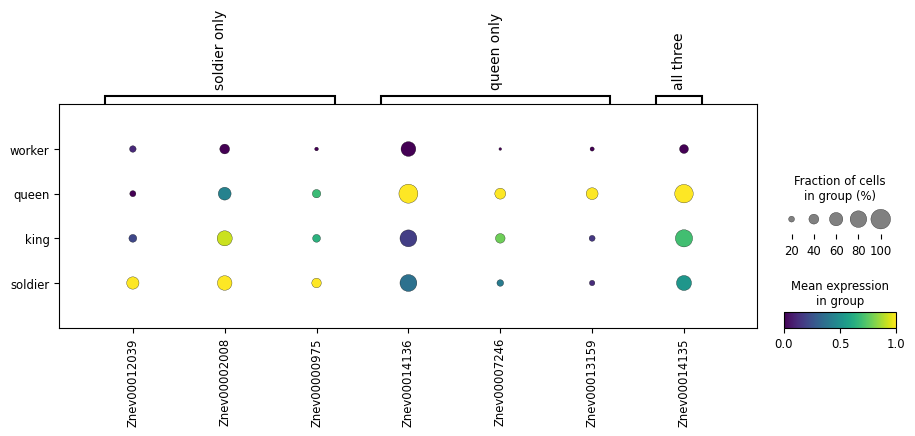

intestinal progenitor like


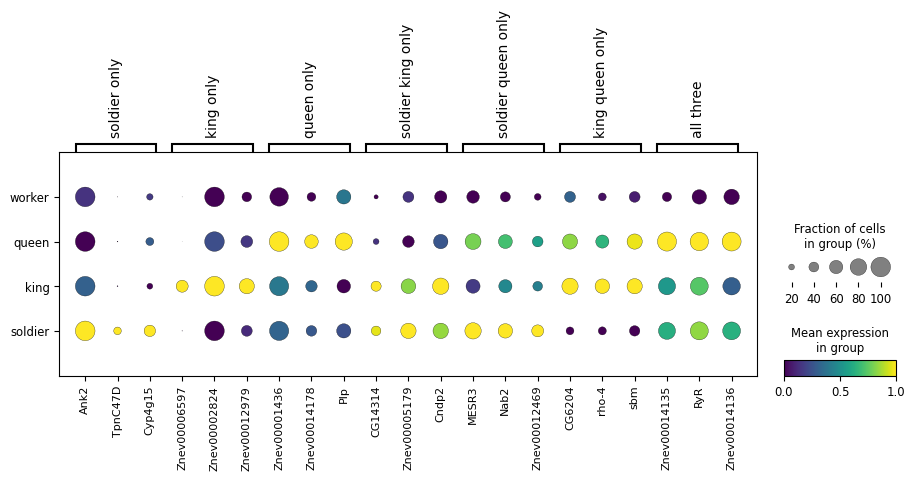

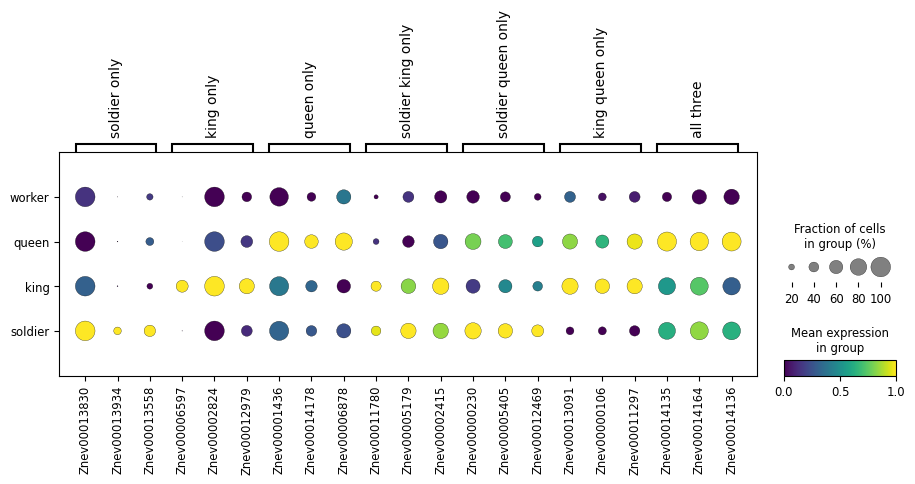

antimicrobial


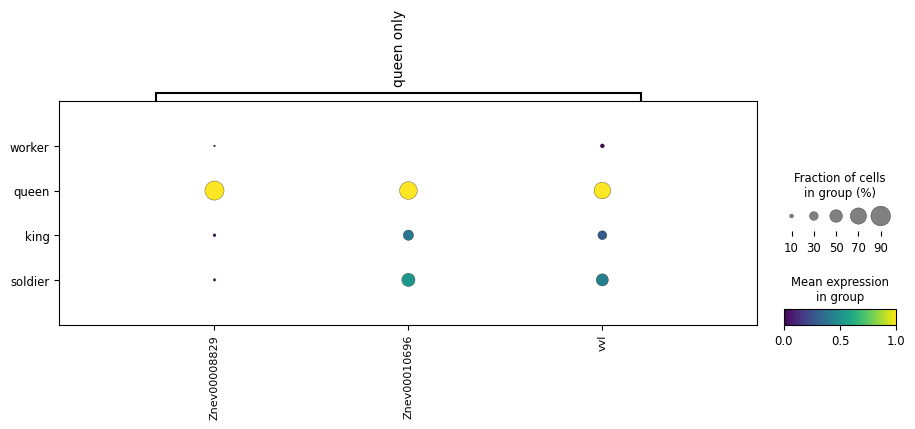

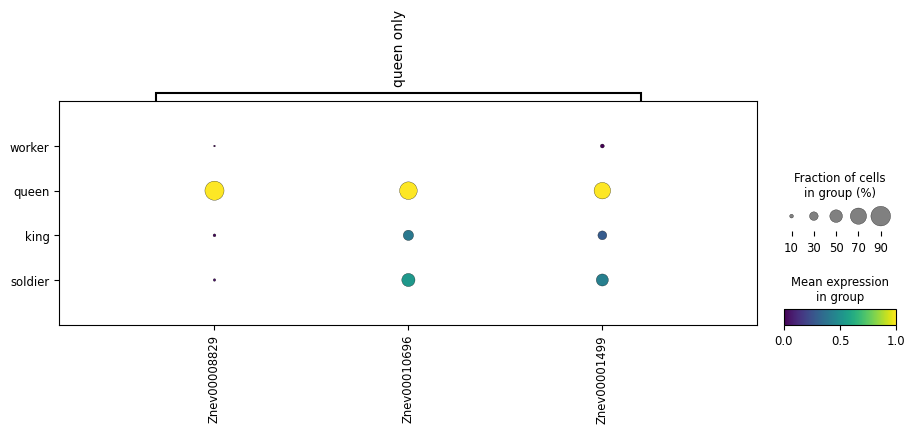

hemocyte


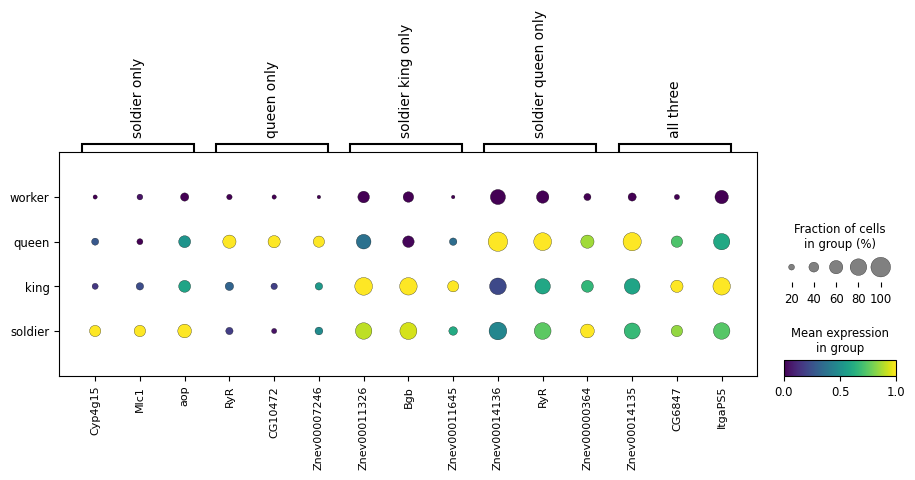

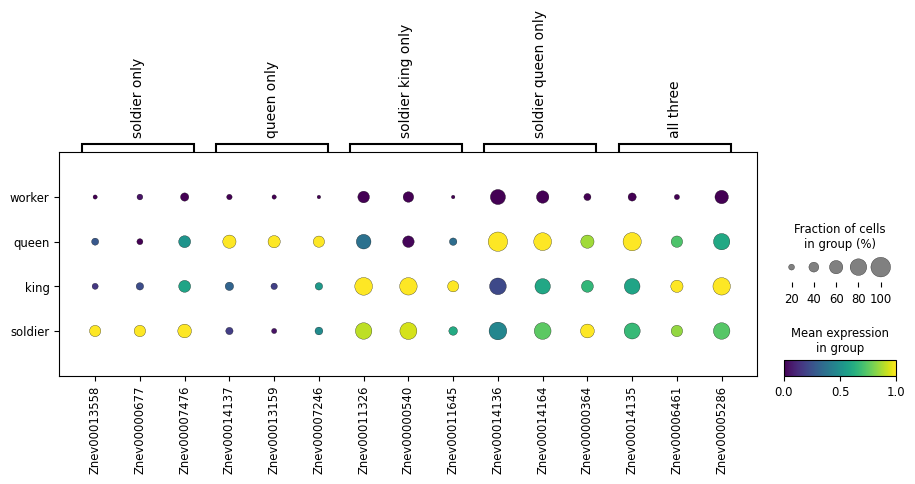

crystal cell


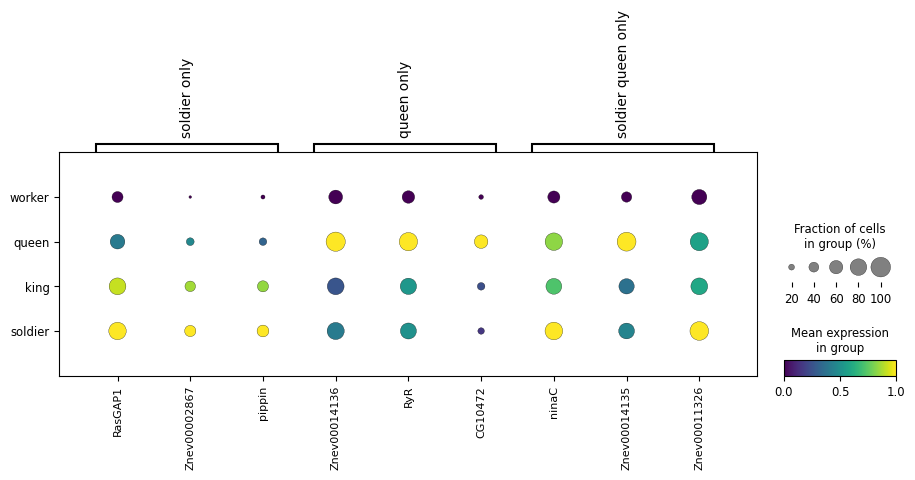

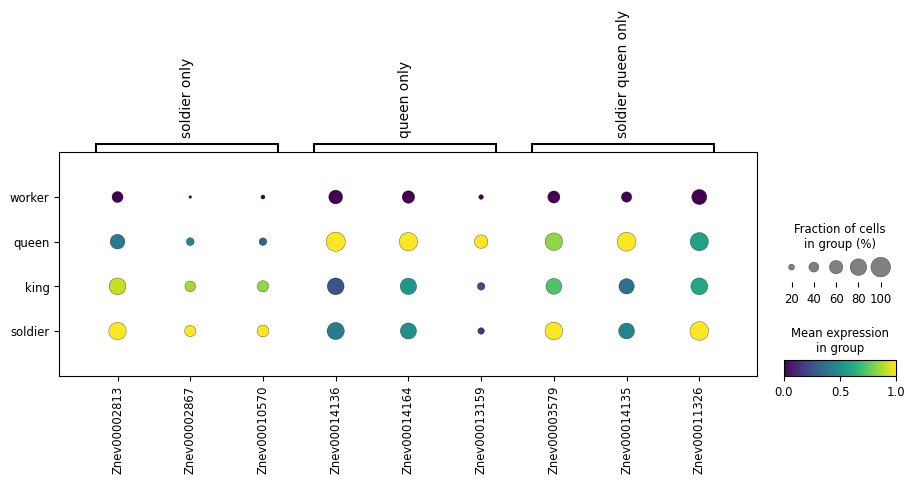

CNS neuron


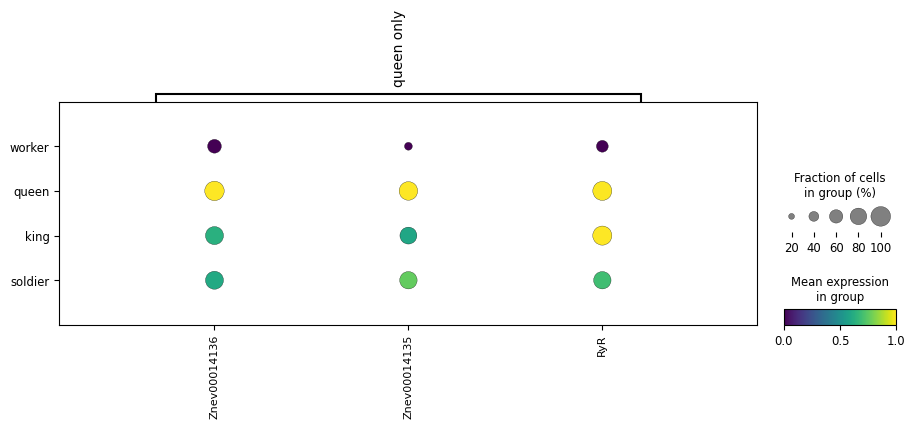

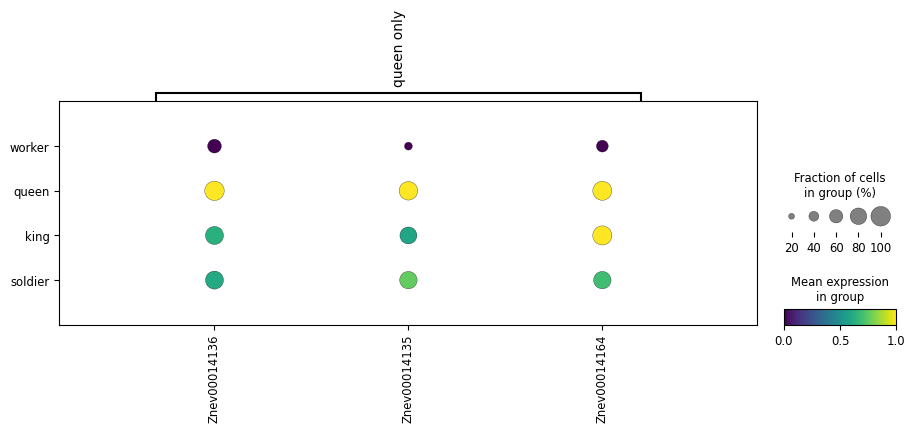

cardiac cell


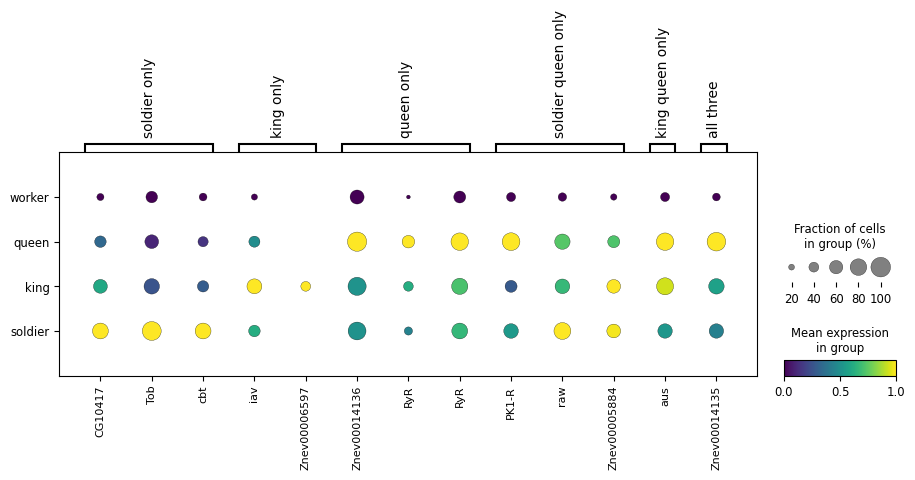

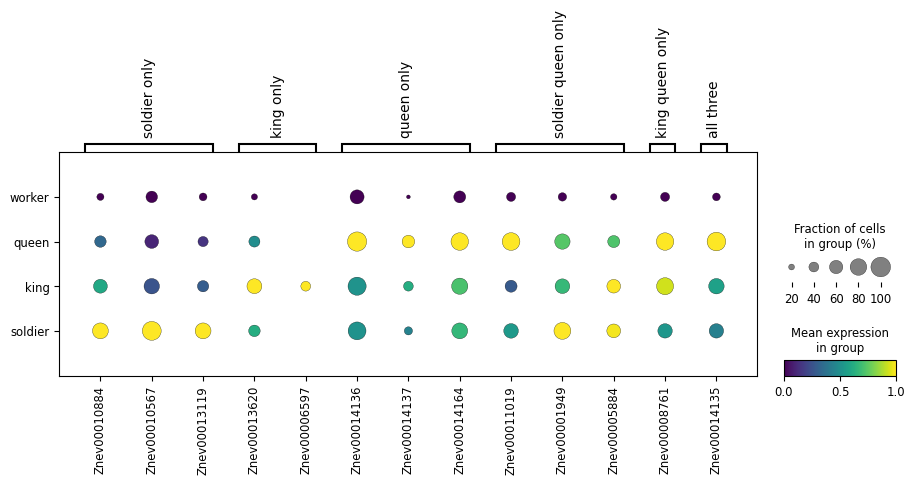

gustatory neuron


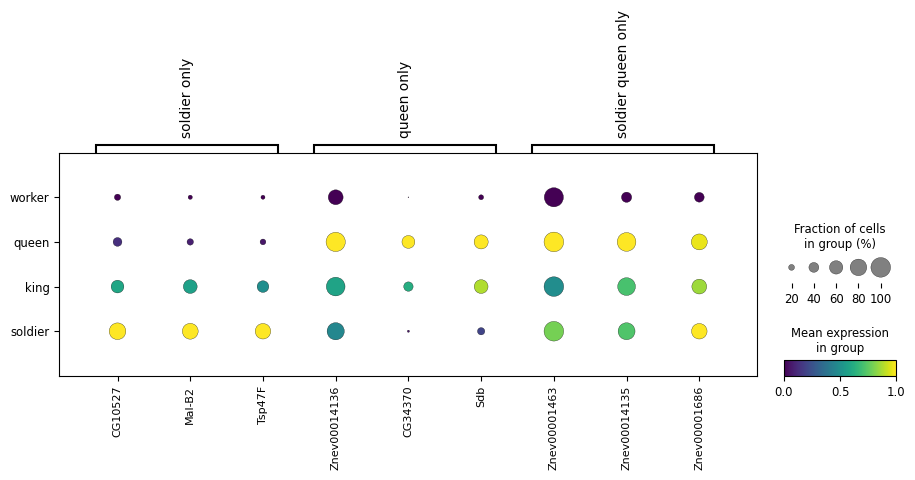

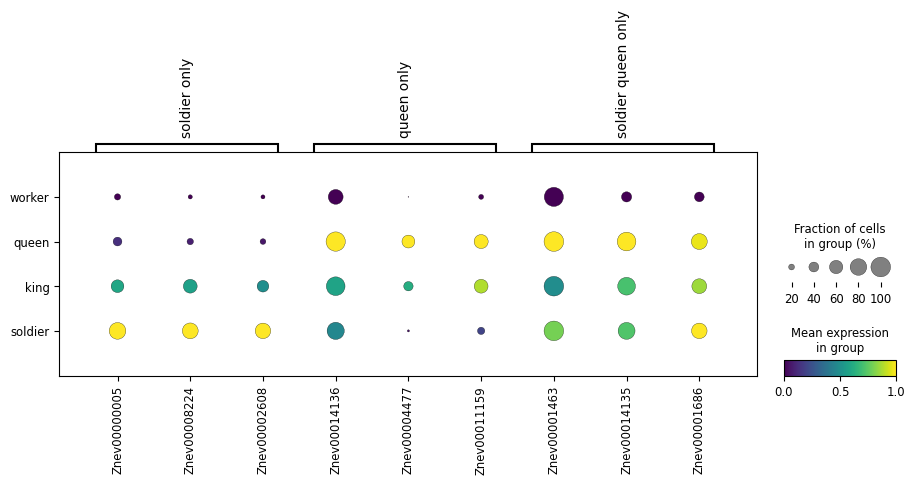

T2


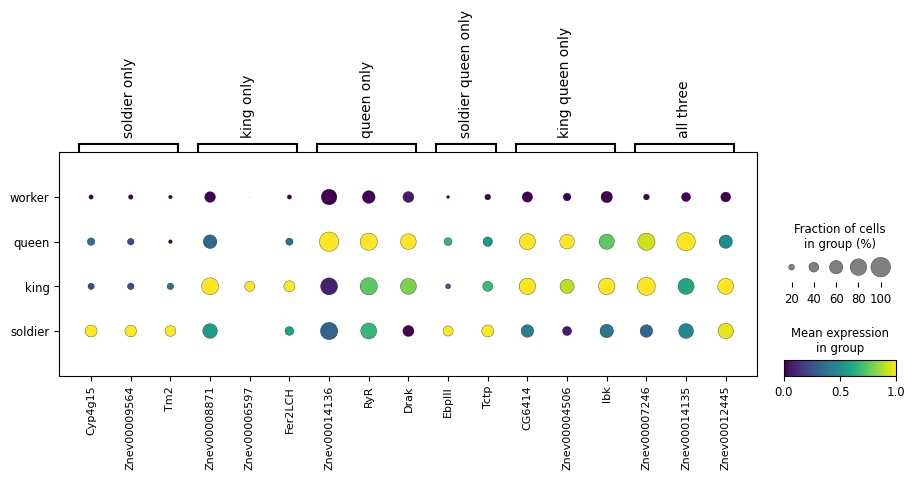

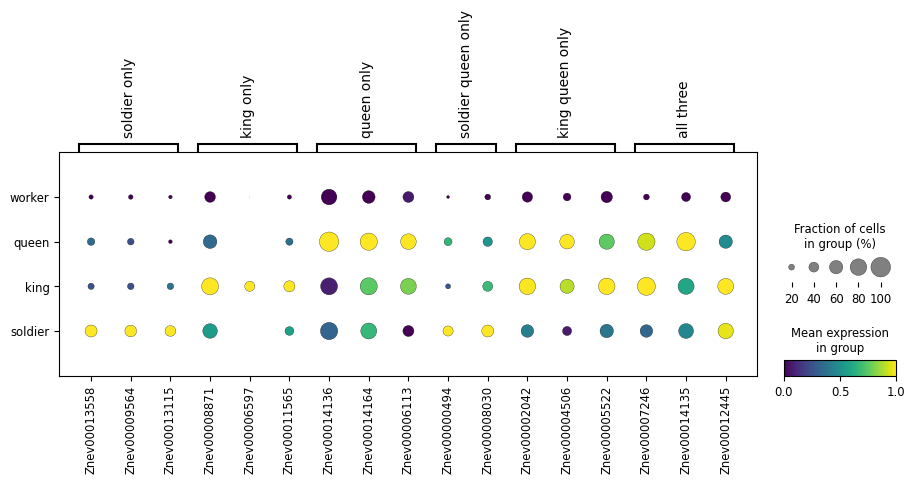

oenocyte


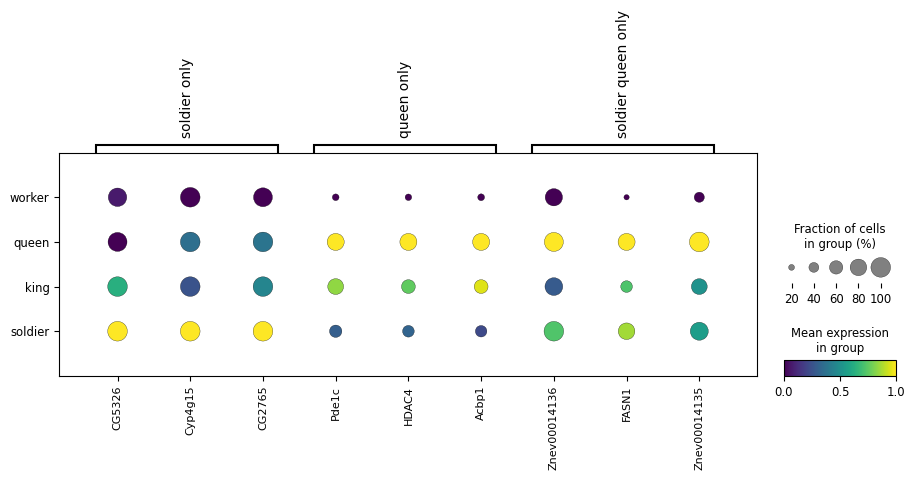

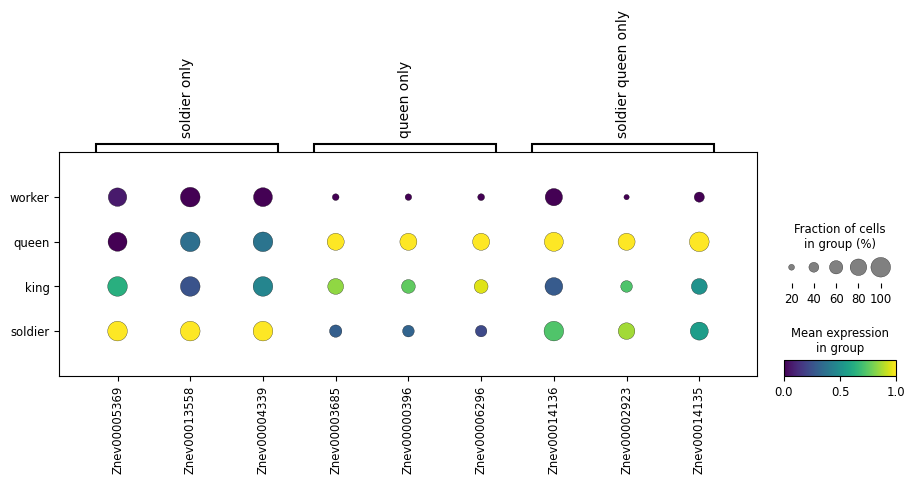

[INFO] Malpighian tubule stellate: no genes to plot.
excretory


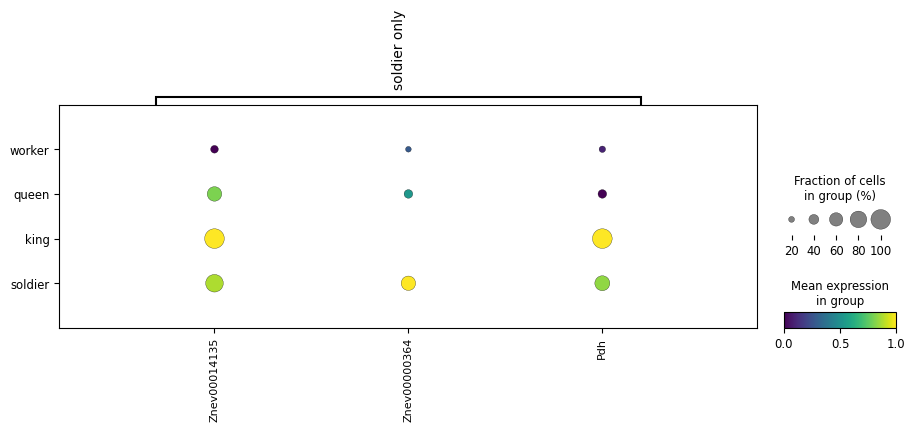

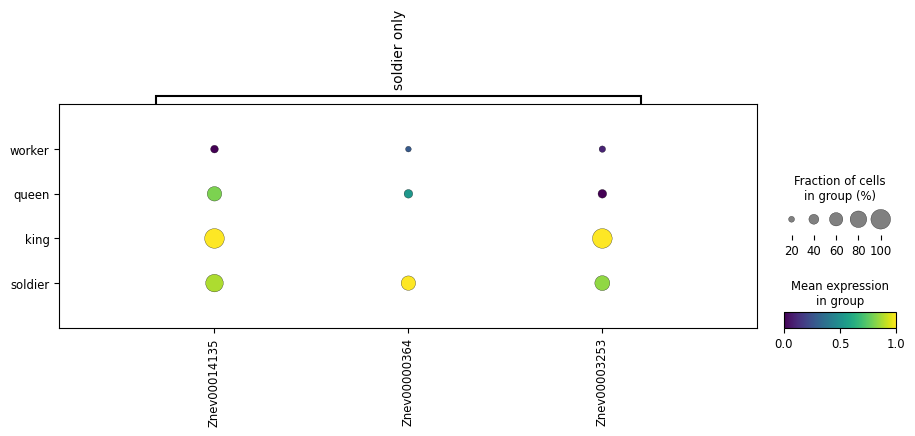

[INFO] female reproductive system: no genes to plot.


In [47]:
# ============================================================
# 4) Top-3 genes per Venn category per cell type
#     (soldier_only, king_only, queen_only, soldier_king_only, soldier_queen_only, king_queen_only, all_three)
# ============================================================
def _rank_involved(gene, tables):
    """
    Combine evidence across the involved castes:
    rank primary: sum(scores), secondary: sum(logFC), tertiary: min(pval_adj or pval).
    """
    sc_sum = 0.0
    lfc_sum = 0.0
    p_vals = []
    for t in tables:
        row = t.loc[t["names"] == gene]
        if not row.empty:
            sc_sum += float(row["scores"].iloc[0]) if pd.notnull(row["scores"].iloc[0]) else 0.0
            lfc_sum += float(row["logfoldchanges"].iloc[0]) if pd.notnull(row["logfoldchanges"].iloc[0]) else 0.0
            pv = row["pvals_adj"].iloc[0] if "pvals_adj" in row.columns and pd.notnull(row["pvals_adj"].iloc[0]) else row["pvals"].iloc[0]
            p_vals.append(float(pv) if pd.notnull(pv) else 1.0)
        else:
            p_vals.append(1.0)
    min_p = min(p_vals) if p_vals else 1.0
    return (-sc_sum, -lfc_sum, min_p)  # sort ascending -> desc for scores/lfc via negatives

category_order = [
    "soldier_only", "king_only", "queen_only",
    "soldier_king_only", "soldier_queen_only", "king_queen_only",
    "all_three",
]

top_genes = {}  # top_genes[cell_type][category] -> list of up to 3 genes
for ct, d in de_tables.items():
    S_df = d.get("soldier", pd.DataFrame(columns=["names"]))
    K_df = d.get("king",    pd.DataFrame(columns=["names"]))
    Q_df = d.get("queen",   pd.DataFrame(columns=["names"]))

    S = set(S_df["names"].astype(str)) if not S_df.empty else set()
    K = set(K_df["names"].astype(str)) if not K_df.empty else set()
    Q = set(Q_df["names"].astype(str)) if not Q_df.empty else set()

    all_three = S & K & Q
    SK_only = (S & K) - all_three
    SQ_only = (S & Q) - all_three
    KQ_only = (K & Q) - all_three
    S_only = S - (K | Q)
    K_only = K - (S | Q)
    Q_only = Q - (S | K)

    cats = {
        "soldier_only": S_only,
        "king_only": K_only,
        "queen_only": Q_only,
        "soldier_king_only": SK_only,
        "soldier_queen_only": SQ_only,
        "king_queen_only": KQ_only,
        "all_three": all_three,
    }

    ct_top = {}
    for cat, genes in cats.items():
        if not genes:
            ct_top[cat] = []
            continue

        if cat == "soldier_only":
            tables = [S_df]
        elif cat == "king_only":
            tables = [K_df]
        elif cat == "queen_only":
            tables = [Q_df]
        elif cat == "soldier_king_only":
            tables = [S_df, K_df]
        elif cat == "soldier_queen_only":
            tables = [S_df, Q_df]
        elif cat == "king_queen_only":
            tables = [K_df, Q_df]
        elif cat == "all_three":
            tables = [S_df, K_df, Q_df]
        else:
            tables = [S_df, K_df, Q_df]

        ranked = sorted(list(genes), key=lambda g: _rank_involved(g, tables))
        ct_top[cat] = ranked[:3]  # top 3 per category

    top_genes[ct] = ct_top

# ============================================================
# (NEW) FORCED INCLUSIONS for dotplots ONLY
# - Keep exactly 3 genes per category.
# - For the specified cell types, include the requested genes in whichever
#   Venn category they naturally fall (based on DE sets). If included,
#   they replace one of the default top-3.
# ============================================================
forced_genes = {
    "fat cell": [
        "Znev00004477",
        "Znev00014136",
        "Znev00000502",
        "Znev00012023",
        "Znev00011220",
    ],
    "muscle cell": [
        "Znev00013934",
        "Znev00013115",
        "Znev00010825",
        "Znev00000677",
    ],
}

def _category_for_gene(g, S, K, Q):
    inS = g in S; inK = g in K; inQ = g in Q
    if inS and inK and inQ:
        return "all_three"
    if inS and inK:
        return "soldier_king_only"
    if inS and inQ:
        return "soldier_queen_only"
    if inK and inQ:
        return "king_queen_only"
    if inS:
        return "soldier_only"
    if inK:
        return "king_only"
    if inQ:
        return "queen_only"
    return None

for ct, gene_list in forced_genes.items():
    if ct not in top_genes:
        continue

    # reconstruct S/K/Q from de_tables for this cell type
    d = de_tables.get(ct, {})
    S_df = d.get("soldier", pd.DataFrame(columns=["names"]))
    K_df = d.get("king",    pd.DataFrame(columns=["names"]))
    Q_df = d.get("queen",   pd.DataFrame(columns=["names"]))
    S = set(S_df["names"].astype(str)) if not S_df.empty else set()
    K = set(K_df["names"].astype(str)) if not K_df.empty else set()
    Q = set(Q_df["names"].astype(str)) if not Q_df.empty else set()

    for g in gene_list:
        cat = _category_for_gene(g, S, K, Q)
        if cat is None:
            # not DE vs worker in any caste → skip silently
            continue
        existing = top_genes[ct].get(cat, [])
        if g in existing:
            continue
        # Prepend the forced gene, keep uniqueness and cap at 3
        new_list = [g] + [x for x in existing if x != g]
        top_genes[ct][cat] = new_list[:3]

# ============================================================
# 5) Scanpy Dotplots of top-3 per category (per cell type), with Fly ortholog labels on x-axis
#     NOTE: castes (groups) are shown on the Y-axis in Scanpy dotplot; we set order to worker→queen→king→soldier.
# ============================================================
def _make_display_labels_for_genes(genes, adata, label_col="dmel_gene_symbol"):
    """
    Build display labels from adata.var[label_col], falling back to the gene ID if missing/empty/Nan.
    Returns a list aligned to `genes`.
    """
    if label_col in adata.var.columns:
        labels_src = adata.var[label_col].astype(str)
    else:
        labels_src = pd.Series(index=adata.var_names, dtype=object)

    # treat empty/NaN/"nan" as missing
    fallback_mask = labels_src.isna() | (labels_src.str.lower() == "nan") | (labels_src.str.strip() == "")
    labels_map = labels_src.where(~fallback_mask, other=labels_src.index)  # Series indexed by gene ID

    # build in the requested order
    return [labels_map.get(g, g) for g in genes]

def plot_dotplots_top3_per_category(
    adata,
    top_genes,
    cell_type_col="paper_cell_type_annotation",
    caste_col="caste",
    castes_order=("worker","queen","king","soldier"),  # <-- requested order
    category_order=(
        "soldier_only", "king_only", "queen_only",
        "soldier_king_only", "soldier_queen_only", "king_queen_only",
        "all_three",
    ),
    standard_scale="var",   # or None
    dot_max=0.45,
    color_map="viridis",
    label_col="dmel_gene_symbol",
    xtick_fontsize=8,
):
    import scanpy as sc

    for ct, cats in top_genes.items():
        # build var_names grouped by category
        var_names = []
        var_group_positions = []
        var_group_labels = []
        start = 0
        for cat in category_order:
            genes = [g for g in cats.get(cat, []) if g in adata.var_names]
            if not genes:
                continue
            var_names.extend(genes)
            end = start + len(genes) - 1
            var_group_positions.append((start, end))
            var_group_labels.append(cat.replace("_", " "))
            start = end + 1

        if not var_names:
            print(f"[INFO] {ct}: no genes to plot.")
            continue

        # Build display labels from fly ortholog symbols (fallback to gene ID)
        display_labels = _make_display_labels_for_genes(var_names, adata, label_col=label_col)

        adata_ct = adata[adata.obs[cell_type_col] == ct].copy()
        # ensure caste is categorical + ordered (worker first)
        adata_ct.obs[caste_col] = pd.Categorical(
            adata_ct.obs[caste_col],
            categories=list(castes_order),
            ordered=True
        )
        print(ct)
        # Create dotplot and keep object to tweak tick labels
        dp = sc.pl.dotplot(
            adata_ct,
            var_names=var_names,
            groupby=caste_col,
            categories_order=list(castes_order),   # ✅ worker, queen, king, soldier
            standard_scale=standard_scale,
            #dot_max=dot_max,
            color_map=color_map,
            var_group_positions=var_group_positions,
            var_group_labels=var_group_labels,
            show=False,
            return_fig=True,
            title=f"",
            figsize=(10.8,2.9),
        ).style(dot_edge_color="black", dot_edge_lw=0.2)
        # Replace bottom x tick labels with display labels (fly symbols) without editing adata
        main_ax = None
        try:
            axes = dp.get_axes()  # Scanpy >= 1.9.x
            main_ax = axes.get("mainplot_ax", None)
        except Exception:
            main_ax = None

        if main_ax is not None:
            main_ax.set_xticklabels(display_labels, rotation=90, fontsize=xtick_fontsize)

        # Show the figure
        dp.show()

# convenience alias to match your call signature
def top3_per_category(*args, **kwargs):
    return plot_dotplots_top3_per_category(*args, **kwargs)


# ---------------- Dotplot example ----------------
top3_per_category(
    adata,
    top_genes,
    cell_type_col=cell_type_col,
    caste_col=caste_col,
    castes_order=("worker","queen","king","soldier"),  # <-- requested order
    category_order=category_order,
    standard_scale="var",
    #dot_max=0.45,
    color_map="viridis",
    label_col=label_col,     # Fly ortholog label column
    xtick_fontsize=8,
)